In [1]:
%pip install --upgrade scikit-learn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE

# Configuration
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
tcga_df = pd.read_csv('TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('weseq_processed_with_id_and_race_V2.csv')

In [4]:
if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop('CGGA_ID', axis=1)

In [5]:
common_cols = list(set(tcga_df.columns) & set(cgga_df.columns))
tcga_df = tcga_df[common_cols]
cgga_df = cgga_df[common_cols]

print(f"Original TCGA Count: {len(tcga_df)} (Min Age: {tcga_df['Age_at_diagnosis'].min()})")
print(f"Original CGGA Count: {len(cgga_df)} (Min Age: {cgga_df['Age_at_diagnosis'].min()})")

Original TCGA Count: 839 (Min Age: 14.42)
Original CGGA Count: 286 (Min Age: 10)


In [8]:
ADULT_CUTOFF = 18

tcga_adults = tcga_df[tcga_df['Age_at_diagnosis'] >= ADULT_CUTOFF].copy()
cgga_adults = cgga_df[cgga_df['Age_at_diagnosis'] >= ADULT_CUTOFF].copy()

In [9]:
tcga_dropped = len(tcga_df) - len(tcga_adults)
cgga_dropped = len(cgga_df) - len(cgga_adults)

print(f"TCGA: Dropped {tcga_dropped} pediatric cases. New Count: {len(tcga_adults)}")
print(f"CGGA: Dropped {cgga_dropped} pediatric cases. New Count: {len(cgga_adults)}")
print(f"New Min Ages -> TCGA: {tcga_adults['Age_at_diagnosis'].min()}, CGGA: {cgga_adults['Age_at_diagnosis'].min()}")

TCGA: Dropped 2 pediatric cases. New Count: 837
CGGA: Dropped 2 pediatric cases. New Count: 284
New Min Ages -> TCGA: 19.15, CGGA: 19


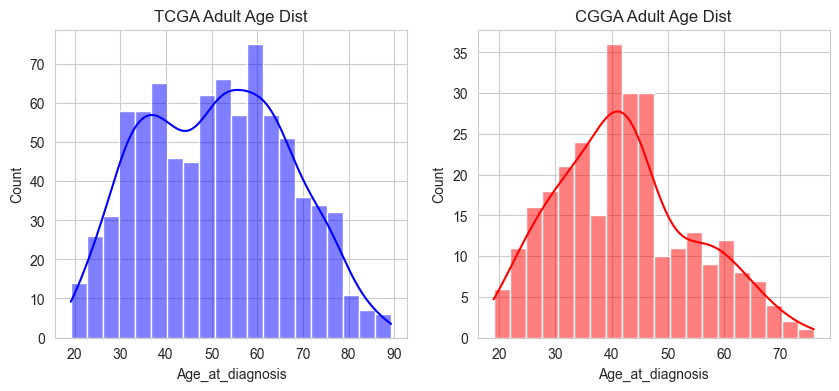

In [10]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(tcga_adults['Age_at_diagnosis'], bins=20, color='blue', kde=True)
plt.title('TCGA Adult Age Dist')
plt.subplot(1, 2, 2)
sns.histplot(cgga_adults['Age_at_diagnosis'], bins=20, color='red', kde=True)
plt.title('CGGA Adult Age Dist')
plt.show()

In [11]:
mean_age = tcga_adults['Age_at_diagnosis'].mean()
std_age = tcga_adults['Age_at_diagnosis'].std()
z_scores = (tcga_adults['Age_at_diagnosis'] - mean_age) / std_age

In [12]:
outliers = tcga_adults[np.abs(z_scores) > 3]

print(f"Adult Mean Age: {mean_age:.2f}")
if len(outliers) == 0:
    print("RESULT: No statistical outliers detected in Adult population.")
else:
    print(f"RESULT: {len(outliers)} statistical outliers detected (Age > 3 SDs from mean).")

Adult Mean Age: 51.02
RESULT: No statistical outliers detected in Adult population.


In [31]:
print(">>> SCENARIO 1 STARTING: 60-20-20 Split <<<")

>>> SCENARIO 1 STARTING: 60-20-20 Split <<<


In [13]:
# Define Features (X) and Target (y)
X = tcga_adults.drop('Grade', axis=1)
y = tcga_adults['Grade']

# --- SPLIT 1: Separate Test Set (20%) ---
# We keep 80% for Model Development (Train + Val)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=42
)

# --- SPLIT 2: Separate Train (60%) and Validation (20%) ---
# The remaining 'temp' data is 80% of the total.
# We want Validation to be 20% of the TOTAL.
# So, relative to 'temp', validation is 20/80 = 0.25 (25%).
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.25, 
    stratify=y_temp, 
    random_state=42
)

print(f"Train Shape: {X_train.shape} (60%)")
print(f"Val Shape:   {X_val.shape} (20%)")
print(f"Test Shape:  {X_test.shape} (20%)")

Train Shape: (501, 23) (60%)
Val Shape:   (168, 23) (20%)
Test Shape:  (168, 23) (20%)


In [14]:
# Initialize Scaler
scaler = MinMaxScaler()

# We need to use .copy() to avoid Pandas warnings
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

# 1. Fit the scaler on TRAIN data
scaler.fit(X_train[['Age_at_diagnosis']])

# 2. Transform TRAIN
X_train['Age_at_diagnosis'] = scaler.transform(X_train[['Age_at_diagnosis']])

# 3. Transform VALIDATION (using Train's math)
X_val['Age_at_diagnosis'] = scaler.transform(X_val[['Age_at_diagnosis']])

# 4. Transform TEST (using Train's math)
X_test['Age_at_diagnosis'] = scaler.transform(X_test[['Age_at_diagnosis']])

print("Normalization Complete.")
print(f"Min Age (Train): {X_train['Age_at_diagnosis'].min()}")
print(f"Max Age (Train): {X_train['Age_at_diagnosis'].max()}")

Normalization Complete.
Min Age (Train): 0.0
Max Age (Train): 0.9999999999999998


In [15]:
print(f"Original Class Distribution (Train): {Counter(y_train)}")

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit and Resample ONLY X_train and y_train
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Balanced Class Distribution (Train): {Counter(y_train_resampled)}")
print("SMOTE applied successfully.")

Original Class Distribution (Train): Counter({0: 291, 1: 210})
Balanced Class Distribution (Train): Counter({0: 291, 1: 291})
SMOTE applied successfully.


In [16]:
# Prepare CGGA
X_cgga = cgga_adults.drop('Grade', axis=1)
y_cgga = cgga_adults['Grade']

# Apply the SAME scaler we trained on TCGA
X_cgga = X_cgga.copy()
X_cgga['Age_at_diagnosis'] = scaler.transform(X_cgga[['Age_at_diagnosis']])

print("CGGA External Validation Set Ready.")
print(X_cgga.head())

CGGA External Validation Set Ready.
   IDH1  IDH2  NOTCH1  Age_at_diagnosis  NF1  CSMD3  PDGFRA  BCOR  Race  \
0     0     0       0          0.454092    0      0       0     0     2   
1     0     0       0          0.325777    0      0       0     0     2   
2     1     0       0          0.197462    0      0       0     0     2   
3     1     0       0          0.340034    0      0       0     0     2   
4     1     0       0          0.083405    0      0       0     0     2   

   Gender  RB1  TP53  FAT4  CIC  PTEN  ATRX  SMARCA4  PIK3R1  MUC16  FUBP1  \
0       1    0     0     0    0     0     0        0       0      0      0   
1       1    0     0     0    0     0     0        0       0      0      0   
2       0    0     0     0    1     0     0        0       0      0      0   
3       0    0     0     0    1     0     0        0       0      0      0   
4       1    0     0     0    1     0     0        0       0      0      0   

   EGFR  GRIN2A  PIK3CA  
0     0       0   

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [20]:
# --- Model 1: Logistic Regression ---
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)


Training Logistic Regression...


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [21]:
# --- Model 2: Random Forest ---
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

Training Random Forest...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
def evaluate_model(model, X, y, dataset_name="Validation"):
    print(f"\n--- {dataset_name} Results ({model.__class__.__name__}) ---")
    
    # Predict
    y_pred = model.predict(X)
    
    # Metrics
    acc = accuracy_score(y, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LGG', 'GBM'])
    disp.plot(cmap='Blues')
    plt.title(f"{dataset_name} Confusion Matrix")
    plt.show()


--- TCGA Internal Validation Results (LogisticRegression) ---
Accuracy: 0.8690
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.88        97
           1       0.82      0.89      0.85        71

    accuracy                           0.87       168
   macro avg       0.87      0.87      0.87       168
weighted avg       0.87      0.87      0.87       168



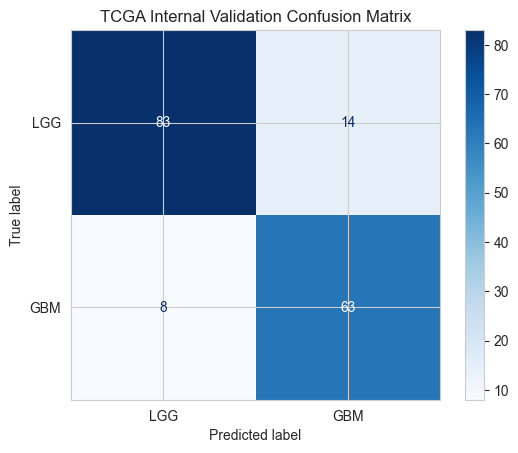

In [23]:
evaluate_model(lr_model, X_val, y_val, "TCGA Internal Validation")


--- TCGA Internal Validation Results (RandomForestClassifier) ---
Accuracy: 0.8512
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87        97
           1       0.84      0.80      0.82        71

    accuracy                           0.85       168
   macro avg       0.85      0.84      0.85       168
weighted avg       0.85      0.85      0.85       168



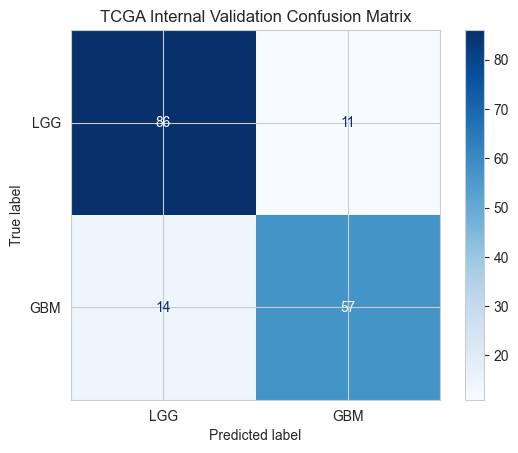

In [24]:
evaluate_model(rf_model, X_val, y_val, "TCGA Internal Validation")


--- CGGA External Test Results (LogisticRegression) ---
Accuracy: 0.6901
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.67      0.73       182
           1       0.55      0.73      0.63       102

    accuracy                           0.69       284
   macro avg       0.68      0.70      0.68       284
weighted avg       0.72      0.69      0.70       284



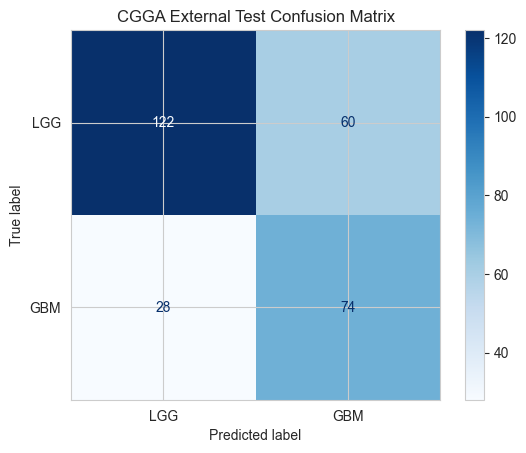

In [25]:
evaluate_model(lr_model, X_cgga, y_cgga, "CGGA External Test")


--- CGGA External Test Results (RandomForestClassifier) ---
Accuracy: 0.7254
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.74      0.78       182
           1       0.60      0.70      0.65       102

    accuracy                           0.73       284
   macro avg       0.71      0.72      0.71       284
weighted avg       0.74      0.73      0.73       284



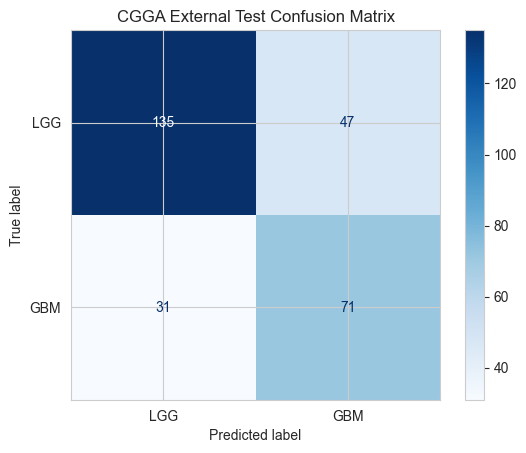

In [26]:
evaluate_model(rf_model, X_cgga, y_cgga, "CGGA External Test")

In [29]:
val_acc_rf = accuracy_score(y_val, rf_model.predict(X_val))
ext_acc_rf = accuracy_score(y_cgga, rf_model.predict(X_cgga))

gap = val_acc_rf - ext_acc_rf

print(f"Random Forest Internal Accuracy: {val_acc_rf:.4f}")
print(f"Random Forest External Accuracy: {ext_acc_rf:.4f}")
print(f"Generalization Gap: {gap:.4f}")

Random Forest Internal Accuracy: 0.8512
Random Forest External Accuracy: 0.7254
Generalization Gap: 0.1258


In [ ]:
print(">>> SCENARIO 2 STARTING: 70-15-15 Split <<<")

In [32]:
# --- 1. Split Logic ---
# A. Split Test Set (15% of Total)
X_temp_2, X_test_2, y_temp_2, y_test_2 = train_test_split(
    X, y, 
    test_size=0.15, 
    stratify=y, 
    random_state=42
)

# B. Split Train/Val from the remaining 85%
# Validation is 15% of TOTAL. Remaining 'temp' is 85%.
# Relative size = 15 / 85 = ~0.176
relative_val_size = 0.15 / 0.85

X_train_2, X_val_2, y_train_2, y_val_2 = train_test_split(
    X_temp_2, y_temp_2, 
    test_size=relative_val_size, 
    stratify=y_temp_2, 
    random_state=42
)

print(f"Train Shape: {X_train_2.shape} (70%)")
print(f"Val Shape:   {X_val_2.shape} (15%)")
print(f"Test Shape:  {X_test_2.shape} (15%)")

Train Shape: (585, 23) (70%)
Val Shape:   (126, 23) (15%)
Test Shape:  (126, 23) (15%)


In [33]:
# --- 2. Normalization (Fit on New Train) ---
scaler_2 = MinMaxScaler()
X_train_2 = X_train_2.copy()
X_val_2 = X_val_2.copy()
X_test_2 = X_test_2.copy()

# Fit on Train, Transform everything else
X_train_2['Age_at_diagnosis'] = scaler_2.fit_transform(X_train_2[['Age_at_diagnosis']])
X_val_2['Age_at_diagnosis'] = scaler_2.transform(X_val_2[['Age_at_diagnosis']])
X_test_2['Age_at_diagnosis'] = scaler_2.transform(X_test_2[['Age_at_diagnosis']])

In [34]:
# --- 3. SMOTE (Train Only) ---
print(f"\nClass Distribution Before SMOTE: {Counter(y_train_2)}")
smote_2 = SMOTE(random_state=42)
X_train_res_2, y_train_res_2 = smote_2.fit_resample(X_train_2, y_train_2)
print(f"Class Distribution After SMOTE:  {Counter(y_train_res_2)}")


Class Distribution Before SMOTE: Counter({0: 339, 1: 246})
Class Distribution After SMOTE:  Counter({0: 339, 1: 339})


In [35]:
rf_model_2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_2.fit(X_train_res_2, y_train_res_2)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
print("\n--- Internal Validation (Scenario 2) ---")
val_acc_2 = accuracy_score(y_val_2, rf_model_2.predict(X_val_2))
print(f"Validation Accuracy: {val_acc_2:.4f}")


--- Internal Validation (Scenario 2) ---
Validation Accuracy: 0.8651


In [38]:
X_cgga_2 = cgga_adults.drop('Grade', axis=1).copy()
X_cgga_2['Age_at_diagnosis'] = scaler_2.transform(X_cgga_2[['Age_at_diagnosis']])
y_cgga_2 = cgga_adults['Grade']

print("\n--- External Validation (CGGA - Scenario 2) ---")
ext_acc_2 = accuracy_score(y_cgga_2, rf_model_2.predict(X_cgga_2))
print(f"External Accuracy: {ext_acc_2:.4f}")


--- External Validation (CGGA - Scenario 2) ---
External Accuracy: 0.6866


In [39]:
gap_2 = val_acc_2 - ext_acc_2
print(f"\nGeneralization Gap (Scenario 2): {gap_2:.4f}")


Generalization Gap (Scenario 2): 0.1785
